In [12]:
import os
import io
import random
import warnings
import collections
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageChops
from scipy import ndimage
from scipy.stats import entropy

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

ROOT = Path(r"C:\Users\Windows\Documents\CASIA2")
AU_DIR = ROOT / 'Au'
TP_DIR = ROOT / 'Tp'
EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

In [23]:
def get_tp_label(path: Path):
    parts = path.stem.split('_')
    # CASIA2 uses the last two source/target tokens to distinguish copy-move vs splicing.
    try:
        return 1 if parts[-3] == parts[-2] else 2
    except Exception:
        return 2

In [24]:
def load_grayscale_image(path, resize_max=512):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        try:
            img = np.array(Image.open(path).convert('L'))
        except Exception:
            return None

    if img.dtype != np.uint8:
        img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    h, w = img.shape
    if resize_max is not None and max(h, w) > resize_max:
        scale = resize_max / max(h, w)
        new_w = max(1, int(w * scale))
        new_h = max(1, int(h * scale))
        img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    return img


def akaze_geometry_features(path, min_dist_px=20, ratio_thresh=0.90, resize_max=512):
    img = load_grayscale_image(path, resize_max=resize_max)
    if img is None:
        return None

    akaze = cv2.AKAZE_create(threshold=0.00035)
    kps, descs = akaze.detectAndCompute(img, None)
    if descs is None or len(kps) < 10:
        return {'cm_score': 0.0, 'n_inliers': 0.0, 'inlier_ratio': 0.0,
                'disp_mean': 0.0, 'disp_std': 0.0, 'angle_std': 0.0, 'cluster_compactness': 0.0}

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw = bf.knnMatch(descs, descs, k=4)

    candidates = []
    for trip in raw:
        non_self = [m for m in trip if m.queryIdx != m.trainIdx]
        if len(non_self) < 2:
            continue

        m, n = non_self[0], non_self[1]
        if m.distance <= ratio_thresh * n.distance:
            pt1 = np.array(kps[m.queryIdx].pt, dtype=np.float32)
            pt2 = np.array(kps[m.trainIdx].pt, dtype=np.float32)
            displacement = pt2 - pt1
            if np.linalg.norm(displacement) > min_dist_px:
                candidates.append((pt1, pt2, displacement))

    if len(candidates) < 8:
        return {'cm_score': 0.0, 'n_inliers': 0.0, 'inlier_ratio': 0.0,
                'disp_mean': 0.0, 'disp_std': 0.0, 'angle_std': 0.0, 'cluster_compactness': 0.0}

    displacements = np.array([c[2] for c in candidates], dtype=np.float32)
    quantized = np.round(displacements / 4.0).astype(np.int16)
    keys, counts = np.unique(quantized, axis=0, return_counts=True)
    best_key = keys[np.argmax(counts)]
    mask = np.all(quantized == best_key, axis=1)

    inliers = [c for c, keep in zip(candidates, mask) if keep]
    n_inliers = len(inliers)
    inlier_ratio = n_inliers / max(len(candidates), 1)

    if n_inliers == 0:
        return {'cm_score': 0.0, 'n_inliers': 0.0, 'inlier_ratio': 0.0,
                'disp_mean': 0.0, 'disp_std': 0.0, 'angle_std': 0.0, 'cluster_compactness': 0.0}

    displacements = np.array([c[2] for c in inliers], dtype=np.float32)
    lengths = np.linalg.norm(displacements, axis=1)
    angles = np.arctan2(displacements[:, 1], displacements[:, 0])

    disp_mean = float(lengths.mean())
    disp_std = float(lengths.std())
    angle_std = float(angles.std())

    pts = np.array([c[0] for c in inliers], dtype=np.float32)
    centroid = pts.mean(axis=0)
    cluster_compactness = float(np.mean(np.linalg.norm(pts - centroid, axis=1)))

    cm_score = float((1 - np.exp(-n_inliers / 12.0)) * (0.5 + 0.5 * inlier_ratio))

    return {'cm_score': cm_score, 'n_inliers': float(n_inliers), 'inlier_ratio': float(inlier_ratio),
            'disp_mean': disp_mean, 'disp_std': disp_std, 'angle_std': angle_std, 'cluster_compactness': cluster_compactness}

In [15]:
def ela_features(path, quality=92, block_size=32):
    try:
        img_pil = Image.open(path).convert('RGB')
    except Exception:
        return None

    buf = io.BytesIO()
    img_pil.save(buf, 'JPEG', quality=quality)
    buf.seek(0)

    ela_arr = np.array(ImageChops.difference(img_pil, Image.open(buf).convert('RGB')), dtype=np.float32).mean(axis=2)
    ela_mean = float(ela_arr.mean())
    ela_std = float(ela_arr.std())

    h, w = ela_arr.shape
    bs = max(8, min(block_size, min(h, w) // 8))
    block_means = []
    for r in range(0, h - bs + 1, bs):
        for c in range(0, w - bs + 1, bs):
            block = ela_arr[r:r+bs, c:c+bs]
            block_means.append(block.mean())
    block_means = np.array(block_means) if len(block_means) else np.array([0.0])
    block_std = float(block_means.std())

    p95 = float(np.percentile(ela_arr, 95))
    hist, _ = np.histogram(ela_arr, bins=32, density=True)
    ela_entropy = float(entropy(hist + 1e-8))

    lvar = (ndimage.uniform_filter(ela_arr**2, size=bs) - ndimage.uniform_filter(ela_arr, size=bs)**2)
    lvar_max = float(lvar.max())

    return {'ela_mean': ela_mean, 'ela_std': ela_std, 'block_std': block_std,
            'ela_p95': p95, 'ela_entropy': ela_entropy, 'lvar_max': lvar_max}


FEATURE_NAMES = ['cm_score', 'n_inliers', 'inlier_ratio', 'disp_mean', 'disp_std', 'angle_std', 'cluster_compactness',
                 'ela_mean', 'ela_std', 'block_std', 'ela_p95', 'ela_entropy', 'lvar_max']


In [16]:
def extract_features(path):
    cm = akaze_geometry_features(path)
    ela = ela_features(path)
    # safe defaults
    if cm is None:
        cm = {'cm_score': 0.0, 'n_inliers': 0.0, 'inlier_ratio': 0.0, 'disp_mean': 0.0, 'disp_std': 0.0,
              'angle_std': 0.0, 'cluster_compactness': 0.0}
    if ela is None:
        ela = {'ela_mean': 0.0, 'ela_std': 0.0, 'block_std': 0.0, 'ela_p95': 0.0, 'ela_entropy': 0.0, 'lvar_max': 0.0}

    feat = np.array([
        cm['cm_score'], cm['n_inliers'], cm['inlier_ratio'], cm['disp_mean'], cm['disp_std'], cm['angle_std'],
        cm['cluster_compactness'], ela['ela_mean'], ela['ela_std'], ela['block_std'], ela['ela_p95'], ela['ela_entropy'],
        ela['lvar_max']], dtype=np.float32)
    return feat

In [17]:
def build_dataset(N=500):
    au_paths = sorted([p for p in AU_DIR.iterdir() if p.suffix.lower() in EXTS])
    tp_paths = sorted([p for p in TP_DIR.iterdir() if p.suffix.lower() in EXTS])
    cm_paths = [p for p in tp_paths if get_tp_label(p) == 1]
    sp_paths = [p for p in tp_paths if get_tp_label(p) == 2]

    au_samp = random.sample(au_paths, min(N, len(au_paths)))
    cm_samp = random.sample(cm_paths, min(N, len(cm_paths)))
    sp_samp = random.sample(sp_paths, min(N, len(sp_paths)))

    X = []
    y = []
    for label, paths in [(0, au_samp), (1, cm_samp), (2, sp_samp)]:
        for p in paths:
            try:
                X.append(extract_features(p))
                y.append(label)
            except Exception:
                continue

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    return X, y

In [18]:
def train_and_evaluate(X, y):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    rf = RandomForestClassifier(n_estimators=500, max_depth=18, min_samples_leaf=2,
                                min_samples_split=5, max_features='sqrt', class_weight='balanced_subsample',
                                bootstrap=True, oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_train_s, y_train)
    preds = rf.predict(X_test_s)

    print(classification_report(y_test, preds, target_names=['Authentic', 'Copy-Move', 'Splicing']))
    print('Balanced Accuracy:', balanced_accuracy_score(y_test, preds))
    try:
        print('OOB Score:', rf.oob_score_)
    except Exception:
        pass

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(rf, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
    print('CV Scores:', scores)
    print('Mean CV:', scores.mean(), 'Std CV:', scores.std())

    cm = confusion_matrix(y_test, preds)
    fig, ax = plt.subplots(figsize=(6, 6))
    ConfusionMatrixDisplay(cm, display_labels=['Authentic', 'Copy-Move', 'Splicing']).plot(ax=ax, cmap='Blues', colorbar=False)
    plt.title('Random Forest')
    plt.show()

    imps = rf.feature_importances_
    order = np.argsort(imps)[::-1]
    plt.figure(figsize=(10, 5))
    plt.bar(range(len(FEATURE_NAMES)), imps[order])
    plt.xticks(range(len(FEATURE_NAMES)), [FEATURE_NAMES[i] for i in order], rotation=45, ha='right')
    plt.title('Feature Importance')
    plt.tight_layout()
    plt.show()

    return rf, scaler

X.shape, class counts: (1500, 13) Counter({np.int64(0): 500, np.int64(1): 500, np.int64(2): 500})
              precision    recall  f1-score   support

   Authentic       0.84      0.87      0.85       125
   Copy-Move       0.64      0.60      0.62       125
    Splicing       0.65      0.66      0.66       125

    accuracy                           0.71       375
   macro avg       0.71      0.71      0.71       375
weighted avg       0.71      0.71      0.71       375

Balanced Accuracy: 0.7120000000000001
OOB Score: 0.6853333333333333
CV Scores: [0.65666667 0.73666667 0.70666667 0.69       0.66      ]
Mean CV: 0.6900000000000001 Std CV: 0.029888682361946514


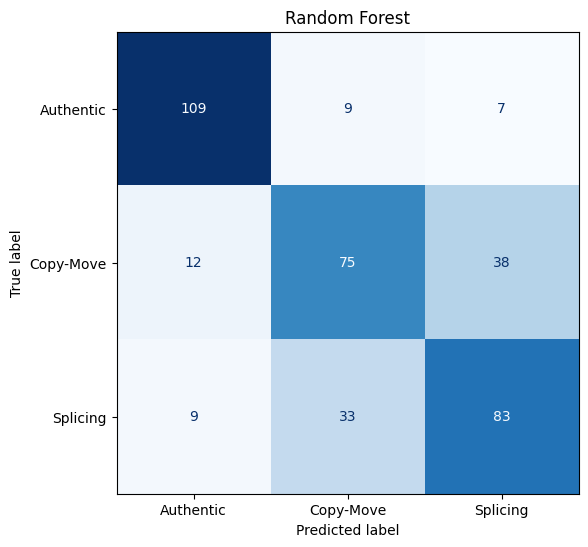

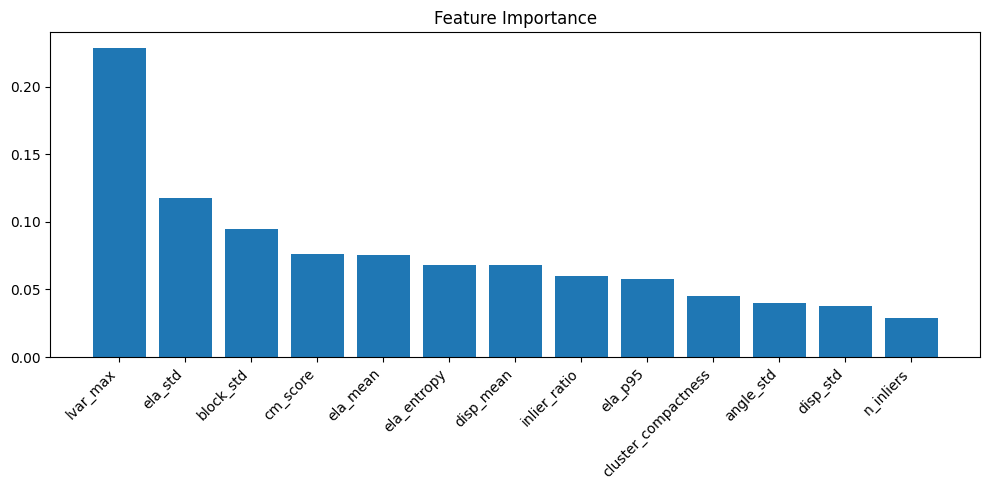

In [25]:
X, y = build_dataset(N=500)
print('X.shape, class counts:', X.shape, collections.Counter(y))
model, scaler = train_and_evaluate(X, y)